In [8]:
import os
import glob
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [9]:
# Configuration
DATA_DIR = 'data/'
TEST_SET_SIZE = 0.20
RANDOM_STATE = 42

In [10]:
# RAVDESS Emotion Code Mapping
EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

def extract_mfcc_features(file_path, n_mfcc=40):
    """
    Loads an audio file and extracts mean MFCC values across time frames.
    Higher MFCC count (40) captures finer timbral characteristics of speech.
    """
    audio_signal, sample_rate = librosa.load(file_path, duration=3, offset=0.5)
    mfccs = librosa.feature.mfcc(y=audio_signal, sr=sample_rate, n_mfcc=n_mfcc)
    return np.mean(mfccs.T, axis=0)

def load_ravdess_dataset(data_path):
    features, labels = [], []
    file_pattern = os.path.join(data_path, "**", "*.wav")
    
    for file in glob.glob(file_pattern, recursive=True):
        file_name = os.path.basename(file)
        parts = file_name.split('-')
        
        # RAVDESS audio filename structure: 03-01-05-01-01-01-01.wav (3rd index = emotion)
        if len(parts) >= 3 and parts[2] in EMOTION_MAP:
            emotion = EMOTION_MAP[parts[2]]
            mfcc_feat = extract_mfcc_features(file)
            
            features.append(mfcc_feat)
            labels.append(emotion)
            
    return np.array(features), np.array(labels)

def evaluate_emotion_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    
    print("=== Emotion Recognition Evaluation ===")
    print(f"Accuracy: {accuracy_score(y_test, predictions):.4f}\n")
    print(classification_report(y_test, predictions))
    
    plt.figure(figsize=(7, 5))
    labels = sorted(list(set(y_test)))
    sns.heatmap(
        confusion_matrix(y_test, predictions, labels=labels),
        annot=True, fmt='d', cmap='Purples',
        xticklabels=labels, yticklabels=labels
    )
    plt.title('Emotion Recognition - Confusion Matrix')
    plt.xlabel('Predicted Emotion')
    plt.ylabel('Actual Emotion')
    plt.tight_layout()
    plt.show()

=== Emotion Recognition Evaluation ===
Accuracy: 0.9340

              precision    recall  f1-score   support

       angry       0.97      1.00      0.99        76
        calm       0.92      0.92      0.92        77
     disgust       0.86      0.82      0.84        77
     fearful       0.95      0.92      0.93        77
       happy       0.88      0.92      0.90        77
     neutral       0.95      1.00      0.97        38
         sad       0.97      0.95      0.96        77
   surprised       0.97      0.97      0.97        77

    accuracy                           0.93       576
   macro avg       0.94      0.94      0.94       576
weighted avg       0.93      0.93      0.93       576



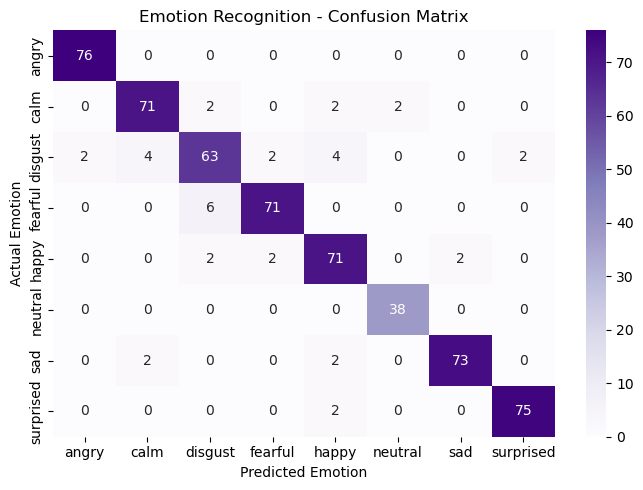

In [12]:
# --- Execution ---
if __name__ == '__main__':
    X, y = load_ravdess_dataset(DATA_DIR)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SET_SIZE, random_state=RANDOM_STATE, stratify=y
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Random Forest as a baseline; deep learning (CNN/1D-CNN) can replace this for higher accuracy
    classifier = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    classifier.fit(X_train_scaled, y_train)
    
    evaluate_emotion_model(classifier, X_test_scaled, y_test)

In [13]:
import glob
import os
print(glob.glob("data/**/*.wav", recursive=True)[:5])

['data\\Actor_01\\03-01-01-01-01-01-01.wav', 'data\\Actor_01\\03-01-01-01-01-02-01.wav', 'data\\Actor_01\\03-01-01-01-02-01-01.wav', 'data\\Actor_01\\03-01-01-01-02-02-01.wav', 'data\\Actor_01\\03-01-02-01-01-01-01.wav']
